# LAB 3: Descriptive Statistical Analysis

**Aim:** In this lab students focus on applying statistical techniques to summarize, explore, and interpret datasets in a meaningful way before applying machine learning models. Students will work with real-world datasets using Python libraries such as NumPy, SciPy, Pandas, and Matplotlib to compute key descriptive measures. The lab covers measures of central tendency including mean, median, and mode to understand the typical values in the data, and measures of dispersion such as minimum, maximum, sum, variance, and standard deviation to analyse data spread and variability. Students will also compute quartiles and percentiles to understand the distribution and relative position of data points and apply correlation and covariance analysis to study relationships and dependencies between variables.

**Dataset:** Students Performance Dataset

### Initialization: Setup libraries and Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://raw.githubusercontent.com/rashida048/Datasets/master/StudentsPerformance.csv'

# Load the dataset directly from URL
try:
    df = pd.read_csv(url)
    print("Dataset loaded successfully!")
except Exception as e:
    print(f"Error loading dataset: {e}")

# Display first few rows
df.head()

Dataset loaded successfully!


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Experiment-1: Data Structure, Central Tendency, and Dispersion
Load the given CSV dataset and display the first few records to understand its structure. Identify numerical and categorical columns and select appropriate features for statistical analysis. Measures of Central Tendency (Compute and interpret mean, median, and mode for selected numerical attributes). Measures of Dispersion (Calculate minimum, maximum, sum, variance, and standard deviation to understand data spread).

In [2]:
# Identify numerical and categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)
print("\n--- Measures of Central Tendency ---")
for col in numerical_cols:
    print(f"\nAttribute: {col}")
    print(f"  Mean:   {df[col].mean():.2f}")
    print(f"  Median: {df[col].median():.2f}")
    print(f"  Mode:   {df[col].mode()[0]}") # Taking the first mode if multipled exist

print("\n--- Measures of Dispersion ---")
for col in numerical_cols:
    print(f"\nAttribute: {col}")
    print(f"  Minimum:  {df[col].min()}")
    print(f"  Maximum:  {df[col].max()}")
    print(f"  Sum:      {df[col].sum()}")
    print(f"  Variance: {df[col].var():.2f}")
    print(f"  Std Dev:  {df[col].std():.2f}")

Categorical Columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
Numerical Columns: ['math score', 'reading score', 'writing score']

--- Measures of Central Tendency ---

Attribute: math score
  Mean:   66.09
  Median: 66.00
  Mode:   65

Attribute: reading score
  Mean:   69.17
  Median: 70.00
  Mode:   72

Attribute: writing score
  Mean:   68.05
  Median: 69.00
  Mode:   74

--- Measures of Dispersion ---

Attribute: math score
  Minimum:  0
  Maximum:  100
  Sum:      66089
  Variance: 229.92
  Std Dev:  15.16

Attribute: reading score
  Minimum:  17
  Maximum:  100
  Sum:      69169
  Variance: 213.17
  Std Dev:  14.60

Attribute: writing score
  Minimum:  10
  Maximum:  100
  Sum:      68054
  Variance: 230.91
  Std Dev:  15.20


## Experiment-2: Quartiles and Percentiles
Compute first quartile (Q1), second quartile (median), and third quartile (Q3) and interpret their significance.

In [3]:
print("--- Quartiles ---")
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q2 = df[col].quantile(0.50) # Same as median
    Q3 = df[col].quantile(0.75)
    print(f"\nAttribute: {col}")
    print(f"  Q1 (25th Percentile): {Q1}")
    print(f"  Q2 (50th Percentile / Median): {Q2}")
    print(f"  Q3 (75th Percentile): {Q3}")
    
print("\nInterpretation:")
print("- Q1 indicates that 25% of the students scored below this value.")
print("- Q2 is the median, indicating that 50% of the students scored below this value.")
print("- Q3 indicates that 75% of the students scored below this value.")
print("- The interquartile range (IQR = Q3 - Q1) represents the middle 50% of the data spread.")

--- Quartiles ---

Attribute: math score
  Q1 (25th Percentile): 57.0
  Q2 (50th Percentile / Median): 66.0
  Q3 (75th Percentile): 77.0

Attribute: reading score
  Q1 (25th Percentile): 59.0
  Q2 (50th Percentile / Median): 70.0
  Q3 (75th Percentile): 79.0

Attribute: writing score
  Q1 (25th Percentile): 57.75
  Q2 (50th Percentile / Median): 69.0
  Q3 (75th Percentile): 79.0

Interpretation:
- Q1 indicates that 25% of the students scored below this value.
- Q2 is the median, indicating that 50% of the students scored below this value.
- Q3 indicates that 75% of the students scored below this value.
- The interquartile range (IQR = Q3 - Q1) represents the middle 50% of the data spread.


## Experiment-3: Correlation and Covariance
Compute correlation coefficients between numerical features and interpret the strength and direction of relationships. Calculate covariance between selected variables and explain how it differs from correlation.

--- Correlation Matrix ---
               math score  reading score  writing score
math score       1.000000       0.817580       0.802642
reading score    0.817580       1.000000       0.954598
writing score    0.802642       0.954598       1.000000


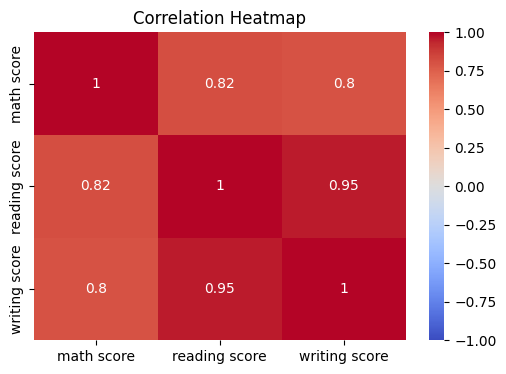


Interpretation of Correlation:
- Reading and writing scores show a very strong positive correlation (typically ~0.95), meaning students who excel in reading also tend to do well in writing.
- Math scores are also strongly positively correlated with reading and writing scores (~0.8), but slightly less so than reading vs writing.


--- Covariance Matrix ---
               math score  reading score  writing score
math score     229.918998     180.998958     184.939133
reading score  180.998958     213.165605     211.786661
writing score  184.939133     211.786661     230.907992

Difference between Correlation and Covariance:
- Covariance indicates the direction of the linear relationship between variables but its value is unscaled, so it ranges from -∞ to +∞, making it hard to interpret the strength of the relationship.
- Correlation is a normalized measure of covariance, scaled to be between -1 and +1, which makes it easy to assess both the direction AND the strength of the linear relat

In [4]:
print("--- Correlation Matrix ---")
correlation_matrix = df[numerical_cols].corr()
print(correlation_matrix)

plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()

print("\nInterpretation of Correlation:")
print("- Reading and writing scores show a very strong positive correlation (typically ~0.95), meaning students who excel in reading also tend to do well in writing.")
print("- Math scores are also strongly positively correlated with reading and writing scores (~0.8), but slightly less so than reading vs writing.")

print("\n\n--- Covariance Matrix ---")
covariance_matrix = df[numerical_cols].cov()
print(covariance_matrix)

print("\nDifference between Correlation and Covariance:")
print("- Covariance indicates the direction of the linear relationship between variables but its value is unscaled, so it ranges from -∞ to +∞, making it hard to interpret the strength of the relationship.")
print("- Correlation is a normalized measure of covariance, scaled to be between -1 and +1, which makes it easy to assess both the direction AND the strength of the linear relationship.")

## Experiment-4: Data Visualization
Plot histograms to analyse data distribution and identify skewness or symmetry. Use boxplots to visualize quartiles, interquartile range, and potential outliers

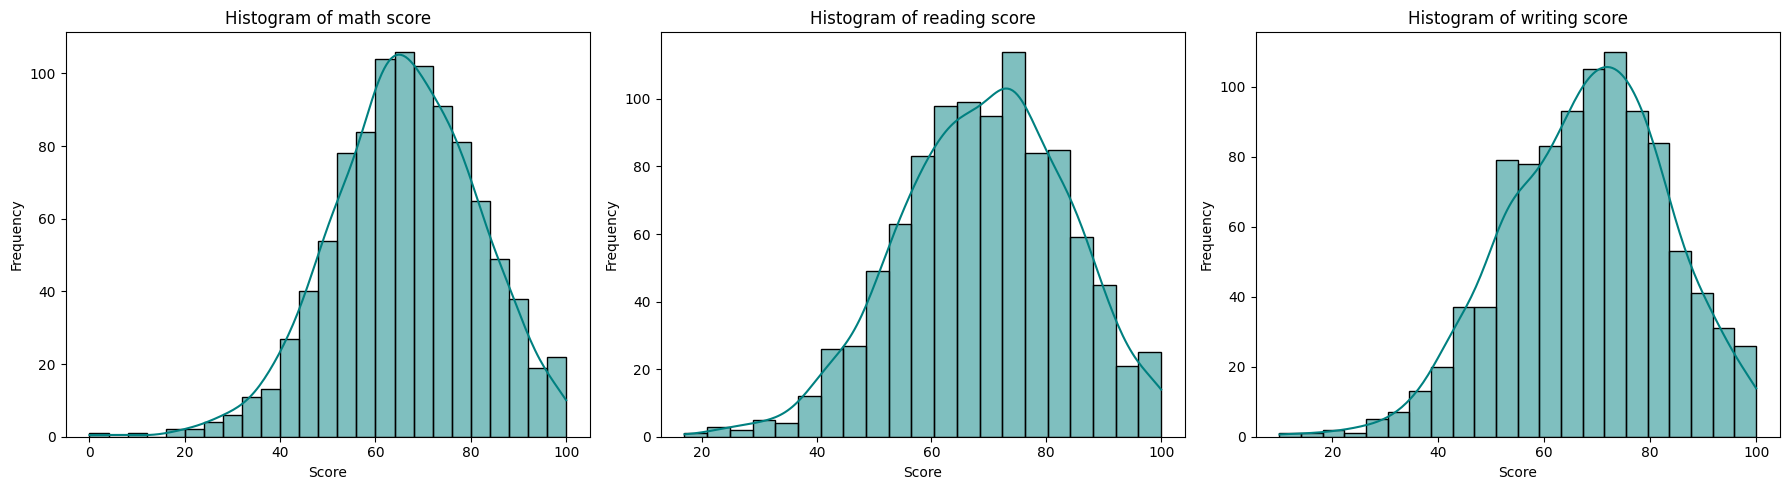

Interpretation of Histograms: The distributions for math, reading, and writing scores are slightly negatively (left) skewed, meaning the mass of the distribution is concentrated on the right side. Most students scored well, with fewer students scoring very low.


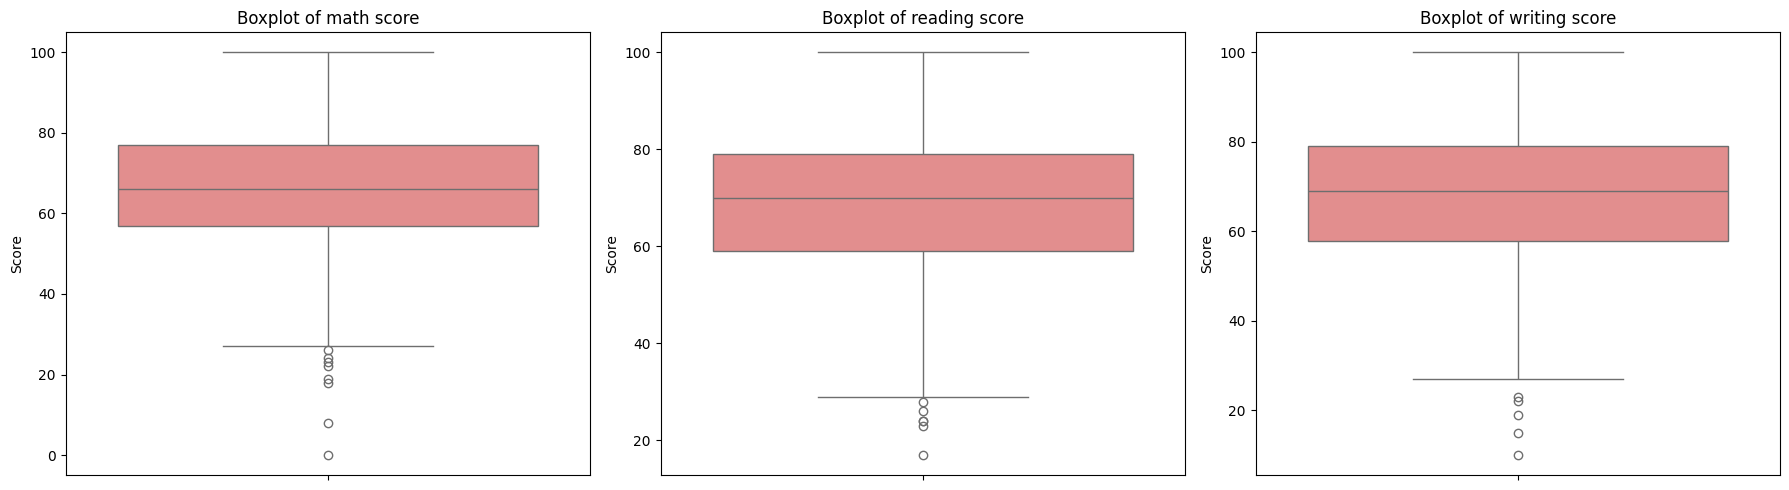

Interpretation of Boxplots:
- The central box represents the Interquartile Range (IQR), from Q1 to Q3.
- The solid line inside the box is the median (Q2).
- The whiskers extend to 1.5 * IQR. Points below the bottom whisker (like the very low scores) are considered potential outliers.


In [5]:
# Histograms
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel('Score')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Interpretation of Histograms: The distributions for math, reading, and writing scores are slightly negatively (left) skewed, meaning the mass of the distribution is concentrated on the right side. Most students scored well, with fewer students scoring very low.")

# Boxplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel('Score')

plt.tight_layout()
plt.show()

print("Interpretation of Boxplots:")
print("- The central box represents the Interquartile Range (IQR), from Q1 to Q3.")
print("- The solid line inside the box is the median (Q2).")
print("- The whiskers extend to 1.5 * IQR. Points below the bottom whisker (like the very low scores) are considered potential outliers.")